In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter

In [13]:
#Params
L = 1000
J = 1
g = 1
k = kb.k_vals(L)
U = kb.U(k,g)
x= np.arange(0,50,dtype=int)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35909/1899081510.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(x,x**(-1/4)*kb.sigma_gen

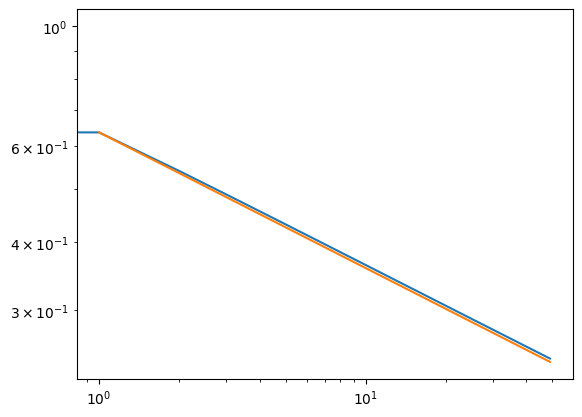

In [17]:
plt.loglog(x,[kb.sigma_general([0,xi],U,k) for xi in x]);
plt.loglog(x,x**(-1/4)*kb.sigma_general([0,1],U,k));

In [ ]:
x= np.arange(0,20,dtype=int)
C_nn = np.array([[ kb.P_n_correlations(n,li,U,k, even = True)-kb.P_n(n,U,k,even=True)**2 for li in x] for n in [1,2,3,4,5,6,7,8]])

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


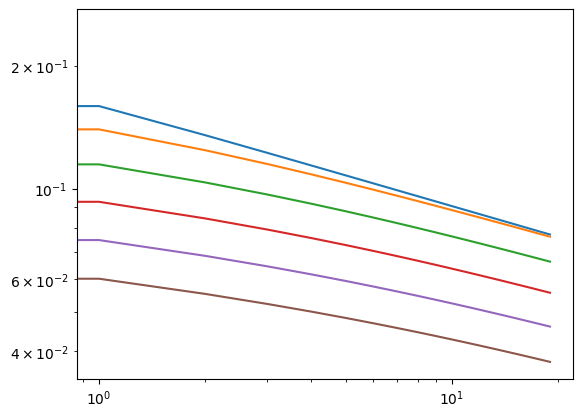

In [ ]:
labels = [ f"n = {n}" for n in [1,2,3,4,5,6,7,8]]
plt.loglog(C_nn.T,label=labels)

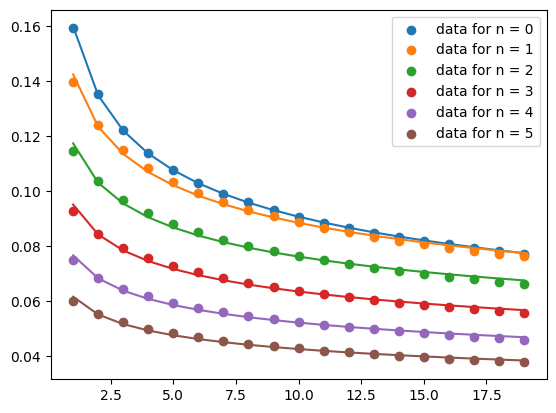

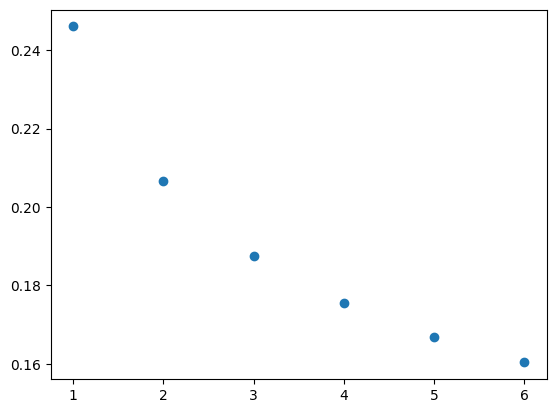

In [ ]:
from scipy.optimize import curve_fit

# Power-law model
def power_func(x, a, b):
    return a * x**b
n = 8
# Exclude x=0
x= np.arange(1,20,dtype=int)
A = []
B = []
for ni in range(n):
    y = C_nn[ni,1:]  # roughly y ≈ a * x^b



    # Fit
    params, _ = curve_fit(power_func, x, y)
    a_fit, b_fit = params
    A.append(a_fit)
    B.append(b_fit)

    plt.scatter(x,y, label = f"data for n = {ni}")
    plt.plot(x,a_fit*x**b_fit)
    plt.legend()
B = np.array(B)
plt.figure()
plt.scatter(np.arange(n)+1,-B)
